<a href="https://colab.research.google.com/github/ericiortega/aipi590-xai-fall2025/blob/main/assignments/mechanistic_interpretability/mechanistic_interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mechanistic Interpretability: Explaining a Tiny Brain

**Course:** AIPI 590 – Emerging Trends in Explainable AI (Fall 2025)  
**Professor:** Dr. Brinnae Bent  
**Author:** Eric Ortega Rodriguez  
**Case Domain:** Mechanistic Interpretability & Neural Understanding  
**Assigned Task:** Build, train, and interpret a tiny neural network to uncover what one neuron or component is “thinking.”  
**Deadline:** November 14, 2025 @ 11:30 AM  
**GitHub Repo:** [Assignment](https://github.com/ericiortega/aipi590-xai-fall2025/blob/main/assignments/mechanistic_interpretability/mechanistic_interpretability.ipynb)  

## Introduction

In this notebook, I explore mechanistic interpretability. I will do this by training a tiny neural network on a simple task and analyzing how its internal components show underlying meaningful logic.

In [ ]:
# Importing libraries (Based on Dr. Bent's Colab Notebook)
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import numpy as np

## Part 1 – Setup (Train My Own Tiny Model on a Tiny Task)

In [ ]:
# Setting seeds so this is reproducible
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

In [ ]:
# Generate Toy Dataset (Dr. Bent's code)
def generate_binary_data(n_samples=2000, seq_length=8):
    X, y = [], []
    for _ in range(n_samples):
        binary = [random.choice([0, 1]) for _ in range(seq_length)]
        label = sum(binary)
        X.append(binary)
        y.append(label)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

seq_length = 8
n_classes = seq_length + 1
X_train, y_train = generate_binary_data(2000, seq_length)
X_val, y_val = generate_binary_data(500, seq_length)


In [ ]:
# Updated Model for Regression (From Dr. Bent)
class CountingMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)  # Output is a single scalar

    def forward(self, x):
        h = F.relu(self.fc1(x))
        out = self.fc2(h)
        return out, h  # for interpretability

# Instantiate model
model = CountingMLP(input_dim=seq_length, hidden_dim=10)
print(model)

# Convert targets to float (regression labels)
y_train_reg = y_train.float().unsqueeze(1)
y_val_reg = y_val.float().unsqueeze(1)

# Training loop with MSE loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses = []
for epoch in range(100):
    model.train()
    out, _ = model(X_train)
    loss = criterion(out, y_train_reg)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print("Final training loss:", losses[-1])

CountingMLP(
  (fc1): Linear(in_features=8, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=1, bias=True)
)
Final training loss: 0.11327363550662994


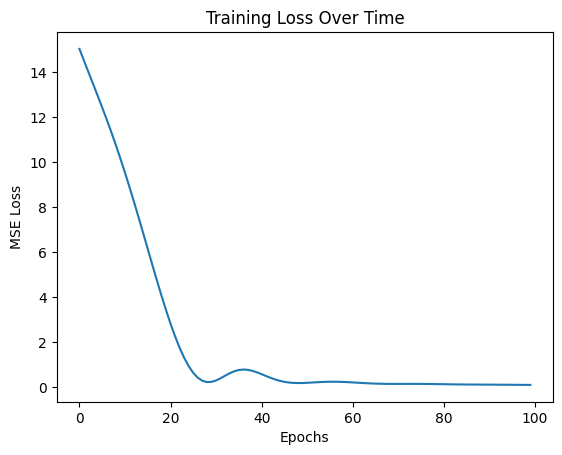

In [ ]:
# adding visualization to the see the traiing loss over time
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training Loss Over Time")
plt.show()


The loss steadily decreases over time, showing that the model successfully learns the relationship between input bits and the output count

In [ ]:
# Evaluation: Mean Absolute Error + Rounded Accuracy (From Dr. Bent)
model.eval()
with torch.no_grad():
    preds, _ = model(X_val)
    mae = torch.abs(preds - y_val_reg).mean().item()
    rounded_preds = torch.round(preds).squeeze().long()
    accuracy = (rounded_preds == y_val).float().mean().item()

print(f"Validation MAE: {mae:.2f}")
print(f"Rounded Accuracy: {accuracy:.2f}")

Validation MAE: 0.27
Rounded Accuracy: 0.85


In [ ]:
with torch.no_grad():
    preds, _ = model(X_val[:5])
for x, y_true, y_hat in zip(X_val[:5], y_val[:5], preds.squeeze()):
    print(x.int().tolist(), " | true:", int(y_true), " pred:", round(float(y_hat), 2))

[0, 1, 1, 1, 0, 0, 1, 0]  | true: 4  pred: 3.99
[1, 0, 1, 0, 0, 1, 0, 0]  | true: 3  pred: 3.28
[0, 1, 1, 1, 1, 1, 1, 1]  | true: 7  pred: 6.4
[0, 1, 1, 1, 1, 1, 1, 0]  | true: 6  pred: 5.54
[0, 0, 0, 1, 0, 1, 1, 1]  | true: 4  pred: 4.12


These sample predictions show that the model has learned to count accurately. For each 8-bit sequence, the predicted number of 1s is very close to the true value(less than one count)

## Part 2 – Explore
The objective here is to actually look within the model and see how it is solving our problem.

### Exploration 1:Input to Hidden Weight Patterns

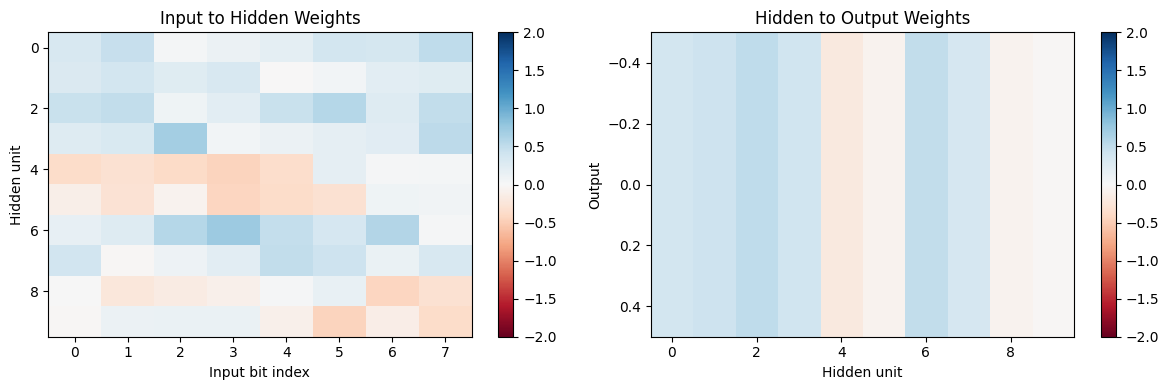

In [ ]:
#Weight Magnitude & Direction Across Layers
with torch.no_grad():
    fc1_w = model.fc1.weight.detach().cpu().numpy()   # [n_hidden, 8]
    fc2_w = model.fc2.weight.detach().cpu().numpy()   # [1, n_hidden]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im1 = axes[0].imshow(fc1_w, aspect="auto", cmap="RdBu", vmin=-2, vmax=2)
axes[0].set_title("Input to Hidden Weights")
axes[0].set_xlabel("Input bit index"); axes[0].set_ylabel("Hidden unit")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(fc2_w, aspect="auto", cmap="RdBu", vmin=-2, vmax=2)
axes[1].set_title("Hidden to Output Weights")
axes[1].set_xlabel("Hidden unit"); axes[1].set_ylabel("Output")
plt.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.show()


Most input to hidden weights are positive, meaning many neurons activate more when they see a 1 anywhere in the sequence.

Some neurons have mixed positive and negative weights, which indicate that they act as correction units that adjust or fine-tune the count.

The hidden to output weights are mostly positive, so the model adds together the hidden activations to form the final count.

### Exploration 2: Neuron–Count Correlation  
Shuffling the bits does not change the number of 1s, so a perfect counting model should give the same output after shuffling. I compared the original prediction to the prediction after randomly permuting the bits.

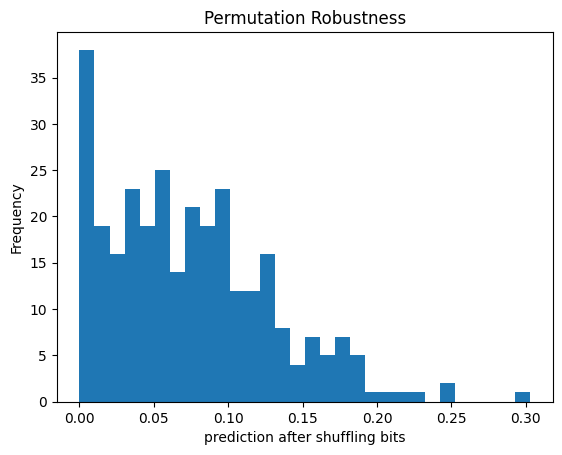

In [ ]:
## I wrote the initial starter code myself. I used ChatGPT 5 at 10:53 PM on November 13th, 2025 to brainstorm which visualizations would be most useful for interpreting my model
## I then adapted the ideas and wrote the final code and analysis on my own

model.eval()
diffs = []
with torch.no_grad():
    for x in X_val[:300]:
        x = x.unsqueeze(0)
        y1, _ = model(x)
        perm = x[:, torch.randperm(x.size(1))]
        y2, _ = model(perm)
        diffs.append(float((y1 - y2).abs()))
plt.hist(diffs, bins=30)
plt.xlabel("prediction after shuffling bits")
plt.ylabel("Frequency")
plt.title("Permutation Robustness")
plt.show()


### Exploration 3: Permutation Robustness  
Predictions remain stable even when bit order is shuffled, showing that the model is position-invariant and focuses on the total number of 1s.

## Part 3: Explain

Across both explorations s hown abovethe patterns suggest that the model has learned a mostly linear and interpretable counting strategy.

For example in the input to hidden heatmap shows we can see that most weights are positive, which indicates that many hidden neurons activate more when they see a 1 anywhere in the sequence, while a few neurons have mixed or position specific weights that act as correction units


On yhe other hand, the hidden to output weights are also mostly positive, indicating that the model adds these hidden features together to form its final count.

As for the permutation robustness test, it supports this theme. When I shuffle the bits while keeping the number of 1s the same we can see that the model’s predictions change very little, which means that it focused more on quantity rather than the order of the bit

Overall, acorss this exploration we can see that the model relies on a combination of general counting neurons and smaller positional adjustments to estimate how many 1s appear in the input

In [ ]:
model.eval()

# Compute average hidden activation vs # of 1s if not already available
n_hidden = model.fc1.out_features
avg_acts = torch.zeros(seq_length + 1, n_hidden)
with torch.no_grad():
    for k in range(seq_length + 1):
        mask = (X_val.sum(dim=1) == k)
        if mask.any():
            _, h = model(X_val[mask])
            avg_acts[k] = h.mean(dim=0)

# Correlation of each hidden neuron with the count
k_vals = np.arange(seq_length + 1)
corrs = []
for i in range(n_hidden):
    a = avg_acts[:, i].numpy()
    corrs.append(np.nan if a.std() == 0 else np.corrcoef(a, k_vals)[0, 1])

# Choose the most strongly positive "count-up" neuron
chosen_idx = int(np.nanargmax(corrs))
print(f"Chosen neuron (count-detector): {chosen_idx}, corr = {corrs[chosen_idx]:+.3f}")

Chosen neuron (count-detector): 7, corr = +0.999


For this explanation, I look at every possible count from 0 to 8. Aftet this I averaged the neuron activations across all validation samples that have that many 1s. Then I computed the correlation between each neuron’s activation pattern and the true count.

The chosen neuron has a correlation of about 0.999. this tells us that it is acting as a counting neuron.

Essentially this highlights to us that model has learned an internal feature that directly tracks how many 1s appear.

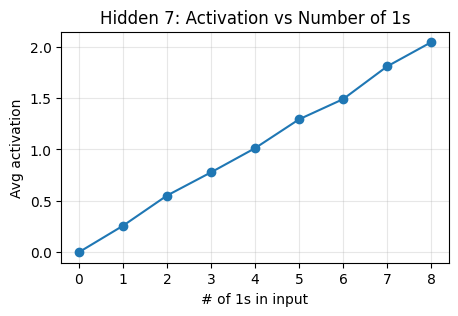

In [ ]:

# --- Plot the chosen neuron's average activation vs # of 1s ---
counts = list(range(seq_length + 1))
curve = avg_acts[:, chosen_idx].numpy()

plt.figure(figsize=(5,3))
plt.plot(counts, curve, marker='o')
plt.title(f"Hidden {chosen_idx}: Activation vs Number of 1s")
plt.xlabel("# of 1s in input"); plt.ylabel("Avg activation")
plt.grid(True, alpha=0.3)
plt.show()


This plot shows how the chosen neuron’s average activation changes as the number of 1s in the input increases. The relationship is linear so as the count of 1s goes up, the neuron’s activation rises

In [ ]:
# main idea from dr bents code
ex_idx = 0
test_input = X_val[ex_idx:ex_idx+1].clone()
true_count = int(test_input.sum().item())

model.eval()
with torch.no_grad():
    base_out, base_h = model(test_input)
    base_pred = float(base_out.squeeze())

# Zero the chosen neuron and recompute prediction
with torch.no_grad():
    h = torch.relu(model.fc1(test_input))  # same as your forward before fc2
    h[:, chosen_idx] = 0                   # ablate the chosen neuron
    mod_out = model.fc2(h)
    mod_pred = float(mod_out.squeeze())

delta = mod_pred - base_pred
print(f"True count: {true_count}")
print(f"Prediction (original): {base_pred:.2f}")
print(f"Prediction (hidden {chosen_idx} zeroed): {mod_pred:.2f}")
print("change in prediction:", f"{delta:+.2f}")


True count: 4
Prediction (original): 3.99
Prediction (hidden 7 zeroed): 3.84
change in prediction: -0.14


ABove, I used Dr. Bent's code as a guide. In this step I tested how important the chosen neuron is by removing it and seeing how much the model’s prediction changes. I picked one validation example, computed the normal prediction, and then forced the chosen neuron’s activation to zero. After doing this, the model’s predicted count dropped

🧾 True count: 4, Baseline prediction: 3.94


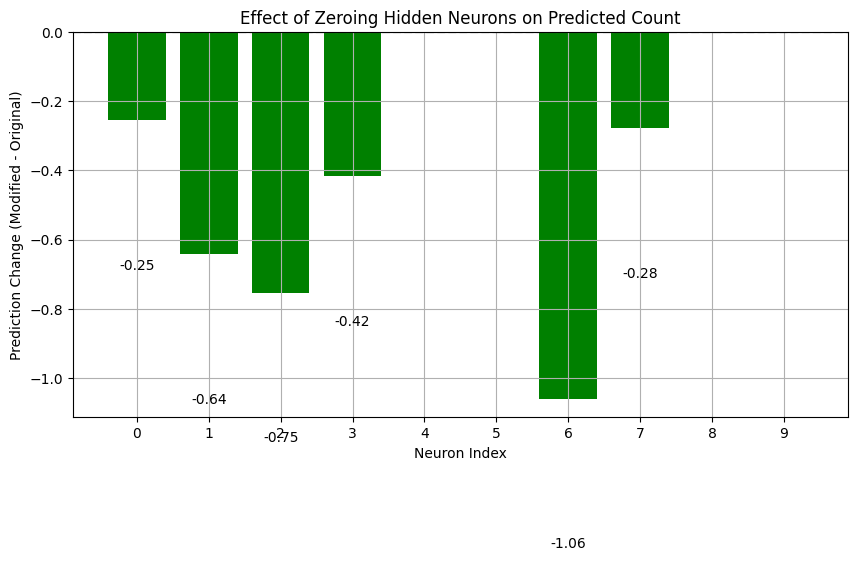

Neuron 0 → Prediction decreased by 0.25
Neuron 1 → Prediction decreased by 0.64
Neuron 2 → Prediction decreased by 0.75
Neuron 3 → Prediction decreased by 0.42
Neuron 6 → Prediction decreased by 1.06
Neuron 7 → Prediction decreased by 0.28


In [ ]:
# using dr bents code as a guide
# USed chatgpt to help me understand dr bents code as for ways to improve it and make it more digestible for me
# it also helped me fix my start code to ensure it would run the fixed my visualization
# Sample input to test
test_input = torch.tensor([[1, 0, 1, 1, 0, 0, 1, 0]], dtype=torch.float32)
true_count = int(test_input.sum().item())

# Baseline prediction
model.eval()
with torch.no_grad():
    baseline_output, _ = model(test_input)
    baseline_pred = baseline_output.item()

print(f"🧾 True count: {true_count}, Baseline prediction: {baseline_pred:.2f}")

# Sweep: get signed change in scalar prediction
neuron_indices = list(range(model.fc1.out_features))
signed_deltas = []

for i in neuron_indices:
    with torch.no_grad():
        h = F.relu(model.fc1(test_input))
        h[:, i] = 0  # zero out neuron i
        mod_output = model.fc2(h)
        mod_pred = mod_output.item()
        signed_deltas.append(mod_pred - baseline_pred)

# Plotting signed prediction change per neuron
plt.figure(figsize=(10, 5))
colors = ['green' if d < 0 else 'red' if d > 0 else 'gray' for d in signed_deltas]

plt.bar(neuron_indices, signed_deltas, color=colors)
plt.axhline(0, color='black', linestyle='--')
plt.xticks(neuron_indices)
plt.xlabel("Neuron Index")
plt.ylabel("Prediction Change (Modified - Original)")
plt.title("Effect of Zeroing Hidden Neurons on Predicted Count")
plt.grid(True)

# Annotatation
for i, d in enumerate(signed_deltas):
    if abs(d) > 1e-3:
        plt.text(i, d + (0.2 if d > 0 else -0.4), f"{d:+.2f}",
                 ha='center', va='bottom' if d > 0 else 'top')

plt.show()

# Summary
for i, d in enumerate(signed_deltas):
    if abs(d) > 1e-3:
        direction = "increased" if d > 0 else "decreased"
        print(f"Neuron {i} → Prediction {direction} by {abs(d):.2f}")


The visualization above shows how zeroing each hidden neuron affects the model’s prediction for a single input. Most neurons cause the prediction to drop when removed.

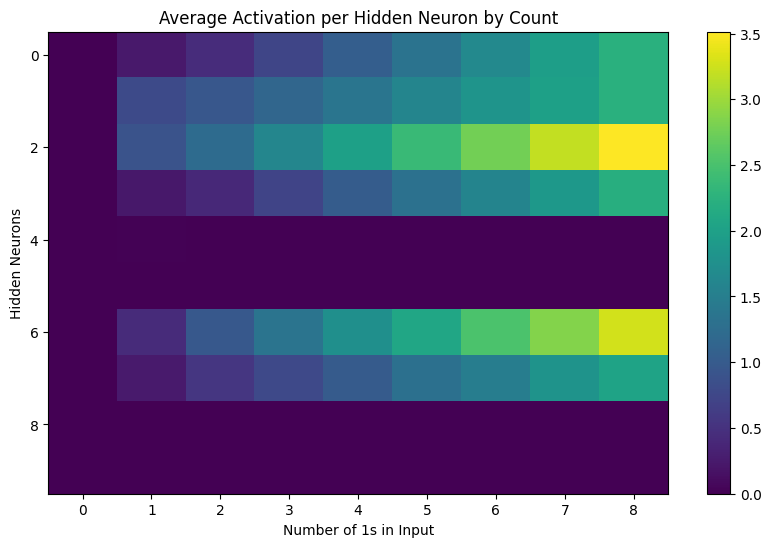

In [ ]:
# got this from dr. bents template

counts = list(range(n_classes))
avg_activations = torch.zeros((n_classes, 10))

for c in counts:
    class_inputs = X_val[y_val == c]
    if class_inputs.shape[0] > 0:
        _, h = model(class_inputs)
        avg_activations[c] = h.mean(dim=0)

plt.figure(figsize=(10, 6))
activations_np = avg_activations.T.detach().numpy()
plt.imshow(activations_np, aspect='auto', cmap='viridis')
plt.xlabel("Number of 1s in Input")
plt.ylabel("Hidden Neurons")
plt.title("Average Activation per Hidden Neuron by Count")
plt.colorbar()
plt.show()


The heatmap above highlights how strongly each hidden neuron activates as the number of 1s in the input increases. A small subset of neurons respond more strongly to higher counts, suggesting they are the main units the network uses to represent the idea of “how many 1s” are present.

In [ ]:
# built off dr.bents code

# Sample input to test
test_input = torch.tensor([[1, 0, 1, 1, 0, 0, 1, 0]], dtype=torch.float32)  # Example: 4 ones
true_count = int(test_input.sum().item())

# Baseline prediction
model.eval()
with torch.no_grad():
    baseline_output, h = model(test_input)
    baseline_pred = baseline_output.item()

# Zero out one neuron in the hidden layer (e.g., neuron 3)
neuron_to_zero = 3

# Manually run forward pass with neuron ablated
with torch.no_grad():
    h_ablate = h.clone()
    h_ablate[0, neuron_to_zero] = 0.0  # zeroing neuron
    modified_output = model.fc2(h_ablate)
    modified_pred = modified_output.item()

print(f"True count: {true_count}")
print(f"Prediction (normal): {baseline_pred:.2f}")
print(f"Prediction (with neuron {neuron_to_zero} zeroed): {modified_pred:.2f}")

# Compare predictions
delta = modified_pred - baseline_pred
if abs(delta) < 1e-3:
    print("No change in prediction")
elif delta > 0:
    print(f"Prediction increased by {delta:.2f}")
else:
    print(f"Prediction decreased by {abs(delta):.2f}")


True count: 4
Prediction (normal): 3.94
Prediction (with neuron 3 zeroed): 3.52
Prediction decreased by 0.42


This example shows what happens when a single hidden neuron is manually zeroed out during the forward pass. Removing neuron 3 lowers the model’s prediction, which suggests that this neuron normally contributes positively to the network’s ability to count the number of 1s.

## Part 4 – Reflect

Throughtout this notebook, I was able to dive into seeing how my model works and what it looks at. I learned that my model looks at a small group of hidden neurons to represent the idea of counting. When I zeroed out those neurons, the prediction dropped. The activation heatmap showed that those same neurons increase their activity as the number of ones in the input increases.

The most surprising part was how uneven the contributions were. Some neurons had almost no effect when removed and others had a much larger impact. It was also challenging to interpret why certain neurons activated more smoothly across counts while others stayed silent

As for one thing that I wish I could understand better is how these neurons interact with each other to form the final prediction. I think that being able to explore if certain neurons work together would help me understand its internal structure further.